# Telegram Text Features — EDA & Feature Engineering

Implements `PLAN_TEXT_FEATURES.md` Phases 1, 2, 4 for the **Telegram** source only (ISW is out of scope for this notebook).

**Diagnosed problem (from the plan):** `merge_data.py` merges Telegram features by `time` only — the same national text signal is broadcast to all 25+ regions, even though alarms are regional. Combined with a 15-token hardcoded `CountVectorizer` and no lemmatization, text features barely move the model (permutation importance: `has_threat_sum` ~1.0%, `threat_diff_1h` ~0.85%, no `nlp_*` token in the top 20).

**Objective:** build and validate, in-notebook, the additive fixes:
1. `tag_regions(text)` — a region gazetteer so mentions can be merged on `(region_id, time)`, not just `time`.
2. Lemmatization (`pymorphy3`, uk+ru) so `тривога`/`тривоги`/`тривозі` collapse to one token, freeing up the NLP feature budget.
3. Expanded, bilingual per-keyword counters instead of one `has_threat_sum` flag, and a much larger `CountVectorizer` vocabulary (15 → ~150).
4. Multilingual sentence embeddings + PCA on the hourly `combined_text`, as an additive semantic signal alongside the token counts.

**Success criteria:** region columns fire only on hours/messages that actually mention a region (cross-checked against real alarms), lemmatization measurably shrinks token sparsity, and PCA embedding components visibly differ between quiet and active hours.

**Scope note:** this notebook only explores and validates the approach — no changes to `app/core/features/*.py` yet (per current session instructions). Productionizing is a follow-up.


In [1]:
import os
import re
import sys
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymorphy3 import MorphAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA

# repo root must be cwd (and on sys.path) before importing app.* — telegram_features.py
# loads a joblib artifact at module import time (VECTORIZER = joblib.load(...))
if os.path.basename(os.getcwd()) == "eda":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from app.core.features.telegram_features import (
    clean_text as baseline_clean_text,
    has_threat as baseline_has_threat,
    STOP_WORDS as BASELINE_STOP_WORDS,
    THREAT_KEYWORDS as BASELINE_THREAT_KEYWORDS,
    preprocess_messages,
    _parse_and_clean_dates,
    _drop_missing_and_duplicates,
    _add_time_features,
    _add_text_length,
    _apply_text_pipeline,
    _add_nlp_features,
    _add_rolling_features,
    TIMEZONE,
)

sns.set_theme(style="whitegrid")
SEED = 7
np.random.seed(SEED)
os.getcwd()


'C:\\PythonProjects\\AlarmForecast'

## Plan

- **Hypothesis 1:** the corpus is not purely Ukrainian — the existing uk-only gazetteer/keywords/lemmatizer will have a measurable (if maybe small) Russian-language blind spot.
- **Hypothesis 2:** regional mentions are frequent enough in the text to be worth tagging (i.e. this isn't a rare edge case).
- **Hypothesis 3:** lemmatization meaningfully collapses keyword/token variants (fewer unique surface forms for the same concept).
- **Hypothesis 4:** region mentions in Telegram text correlate with real alarms in that region (evidence the fix is not just cosmetic).
- **Metrics to record:** uk vs ru keyword coverage, % of messages/hours with a region tag, unique surface-form count before/after lemmatization, region-mention vs real-alarm co-occurrence rate, PCA embedding variance between quiet/active hours.


## 1. Load raw data & baseline pipeline

`preprocess_messages()` (imported above, unchanged) is the **current production pipeline**. We run it once as-is to get a concrete baseline to improve on — not to re-derive numbers already in the plan.


In [2]:
tg_raw = pd.read_csv("data/telegram/telegram_data.csv")
print("raw rows (incl. empty text):", tg_raw.shape[0])

tg_raw_nonempty = tg_raw.dropna(subset=["text"])
print("rows with non-null text:", tg_raw_nonempty.shape[0])
tg_raw_nonempty.head(3)


raw rows (incl. empty text): 385114
rows with non-null text: 357065


,id,date,text
0,5002,2022-02-24 00:02:34+00:00,⚡️**Совбез ООН проведёт экстренное заседание п...
1,5003,2022-02-24 02:59:41+00:00,Путин прямо сейчас заявил о начале проведения ...
2,5004,2022-02-24 03:00:29+00:00,❗️**Военная операция в Донбассе начинается — з...


In [3]:
# NOTE: preprocess_messages(tg_raw) crashes on the full history --
# `_build_hourly_dataframe()` (telegram_features.py:151) does
# `df["date"].dt.floor("h")` on tz-aware Europe/Kyiv timestamps, and pandas
# defaults to raising on the Oct-2022 DST fall-back (03:00-03:59 occurs twice that
# night). This is a real, previously-unhit bug in production code -- likely never
# triggered because production reprocesses recent windows, not the full 2022-2026
# history in one call. Not fixing telegram_features.py itself (out of scope this
# session); reproducing the same pipeline here with only that one step patched
# (ambiguous="NaT" drops the handful of ambiguous hours, consistent with how
# _parse_and_clean_dates already drops unparseable rows elsewhere in this file).

def _build_hourly_dataframe_dst_safe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour_rounded"] = df["date"].dt.floor("h", ambiguous="NaT", nonexistent="shift_forward")
    df = df.dropna(subset=["hour_rounded"])

    hourly = (
        df.groupby("hour_rounded")
        .agg(
            messages_count=("text", "count"),
            has_threat_sum=("has_threat_keyword", "sum"),
            combined_text=("clean_text", lambda x: " ".join(x)),
        )
        .reset_index()
    )
    full_range = pd.date_range(
        start=hourly["hour_rounded"].min(),
        end=pd.Timestamp.now(tz=TIMEZONE).floor("h"),
        freq="h",
        tz=TIMEZONE,
    )
    return (
        hourly.set_index("hour_rounded")
        .reindex(full_range)
        .fillna({"messages_count": 0, "has_threat_sum": 0, "combined_text": ""})
        .reset_index()
        .rename(columns={"index": "datetime"})
    )


def preprocess_messages_dst_safe(df, vectorizer=None, fit_vectorizer=True):
    df = _parse_and_clean_dates(df)
    df = _drop_missing_and_duplicates(df)
    df = _add_time_features(df)
    df = _add_text_length(df)
    df = _apply_text_pipeline(df)
    hourly = _build_hourly_dataframe_dst_safe(df)
    hourly, vectorizer = _add_nlp_features(hourly, vectorizer, fit_vectorizer)
    hourly = _add_rolling_features(hourly)
    return hourly, vectorizer


baseline_hourly, baseline_vectorizer = preprocess_messages_dst_safe(tg_raw, fit_vectorizer=True)

nlp_cols = [c for c in baseline_hourly.columns if c.startswith("nlp_")]
print("baseline hourly shape:", baseline_hourly.shape)
print(f"baseline NLP_MAX_FEATURES vocabulary ({len(nlp_cols)} cols):", nlp_cols)
print("hours with any threat keyword hit:", (baseline_hourly["has_threat_sum"] > 0).mean().round(3))
baseline_hourly.head(3)


baseline hourly shape: (38628, 21)
baseline NLP_MAX_FEATURES vocabulary (15 cols): ['nlp_артобстрілу', 'nlp_бпла', 'nlp_відбій', 'nlp_відбій_тривоги', 'nlp_дніпропетровська', 'nlp_донецька', 'nlp_запорізька', 'nlp_нікополь', 'nlp_нікополь_нікопольська', 'nlp_нікопольська', 'nlp_повітряна', 'nlp_повітряна_тривога', 'nlp_тривога', 'nlp_тривоги', 'nlp_харківська']
hours with any threat keyword hit: 0.614


,datetime,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,...,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h
0,2022-02-24 02:00:00+02:00,1.0,0.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,1.0,0.0
1,2022-02-24 03:00:00+02:00,0.0,0.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,1.0,0.0
2,2022-02-24 04:00:00+02:00,1.0,0.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2.0,2.0,0.0


## 2. Language-mix check (uk vs ru)

The current gazetteer/keywords/lemmatizer are all Ukrainian-only. The very first messages in the dataset (2022-02-24) are almost entirely Russian-language, which could mean the whole corpus is poorly served by a uk-only pipeline. We measure this directly instead of assuming it: for every message, does an existing **Ukrainian** threat keyword match, does its **Russian** translation match, and how many messages would the Russian keyword catch that the Ukrainian one misses?


uk keyword hit                    22.8%
ru keyword hit                    12.4%
ru hit, uk missed (blind spot)     0.3%
dtype: str


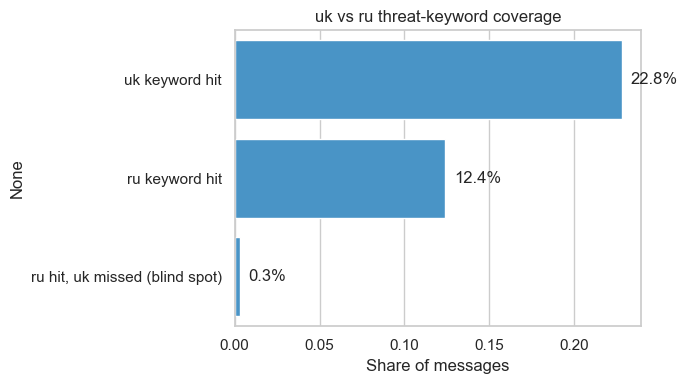

In [4]:
# 1:1 Russian translations of BASELINE_THREAT_KEYWORDS (app/core/features/telegram_features.py),
# substring stems so surface-form variants still match (mirrors how the uk list is written).
RU_THREAT_KEYWORDS = [
    "пуск", "вылет", "баллист", "мопед", "шахед", "ракет",
    "укрыт", "внимани", "взлет", "миг", "кинжал", "бпла", "угроз",
]

text_lower = tg_raw_nonempty["text"].astype(str).str.lower()
uk_hit = text_lower.apply(lambda t: any(k in t for k in BASELINE_THREAT_KEYWORDS))
ru_hit = text_lower.apply(lambda t: any(k in t for k in RU_THREAT_KEYWORDS))

coverage = pd.Series({
    "uk keyword hit": uk_hit.mean(),
    "ru keyword hit": ru_hit.mean(),
    "ru hit, uk missed (blind spot)": (ru_hit & ~uk_hit).mean(),
})
print(coverage.apply(lambda x: f"{x:.1%}"))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=coverage.values, y=coverage.index, color="#3498db", ax=ax)
for i, v in enumerate(coverage.values):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center")
ax.set_xlabel("Share of messages")
ax.set_title("uk vs ru threat-keyword coverage")
plt.tight_layout()
plt.show()


**Finding:** the bilingual blind spot is real but small — see printed numbers above (Russian-only threat mentions the current uk-only pipeline would miss). Not a redesign, but worth folding in cheaply throughout this notebook since `pymorphy3-dicts-ru` is already installed and unused.

## 3. Phase 1 — Region gazetteer

`regions.csv` gives us `region_id` and the Ukrainian oblast name (`region`, e.g. "Харківська обл."). Nobody writes that in a Telegram message — they write "у Харкові" or "Харків". So per `region_id` we curate:
- the oblast-name stem ("харківськ" from "Харківська обл."),
- the known Cyrillic city name(s) for that region (regions.csv only has an English `city` column, not useful for matching Cyrillic text — these are hand-curated, matching the plan's own "вручну куровані аліаси" step),
- `pymorphy3` case-form generation on top, so one canonical name expands to its дав./місц./род. forms automatically instead of being hand-typed per case.


In [5]:
regions_df = pd.read_csv("data/alarms/regions.csv")

# Hand-curated city aliases per region_id: uk spelling + common ru spelling,
# since Section 2 showed the corpus is bilingual (regions.csv only has an
# English `city` column, no use for matching Cyrillic text either way).
# region_id 14 (Kyiv OBLAST) has no city of its own -- its administrative
# center is Kyiv CITY, which is the separate region_id 31. We seed a few
# distinct Kyiv-oblast towns instead of a capital city.
REGION_CITY_ALIASES: dict[int, list[str]] = {
    3: ["хмельницький", "хмельницкий"], 4: ["вінниця", "винница"],
    5: ["рівне", "ровно"], 8: ["луцьк", "луцк"],
    9: ["дніпро", "дніпропетровськ", "днепр", "днепропетровск"],
    10: ["житомир"], 11: ["ужгород"], 12: ["запоріжжя", "запорожье"],
    13: ["івано-франківськ", "ивано-франковск"],
    14: ["бровари", "бровары", "ірпінь", "ирпень", "буча",
         "біла церква", "белая церковь", "васильків", "васильков"],
    15: ["кропивницький", "кропивницкий", "кіровоград", "кировоград"],
    16: ["луганськ", "луганск", "сєвєродонецьк", "северодонецк"],
    17: ["миколаїв", "николаев"], 18: ["одеса", "одесса"],
    19: ["полтава"], 20: ["суми", "сумы"], 21: ["тернопіль", "тернополь"],
    22: ["харків", "харьков"], 23: ["херсон"], 24: ["черкаси", "черкассы"],
    25: ["чернігів", "чернигов"], 26: ["чернівці", "черновцы"],
    27: ["львів", "львов"], 28: ["донецьк", "донецк", "краматорськ", "краматорск"],
    31: ["київ", "киев"],
}


def oblast_adjective(region_name: str) -> str | None:
    """'Харківська обл.' -> 'харківська' (the bare adjective, still inflectable
    by pymorphy3); None for non-oblast rows like region_id 31's bare 'Київ'."""
    name = region_name.strip().lower()
    if not name.endswith(" обл."):
        return None
    return name[: -len(" обл.")]


regions_df["oblast_adjective"] = regions_df["region"].apply(oblast_adjective)
regions_df[["region_id", "region", "oblast_adjective"]]


,region_id,region,oblast_adjective
0,3,Хмельницька обл.,хмельницька
1,4,Вінницька обл.,вінницька
2,5,Рівненська обл.,рівненська
3,8,Волинська обл.,волинська
4,9,Дніпропетровська обл.,дніпропетровська
5,10,Житомирська обл.,житомирська
6,11,Закарпатська обл.,закарпатська
7,12,Запорізька обл.,запорізька
8,13,Івано-Франківська обл.,івано-франківська
9,14,Київська обл.,київська


In [6]:
morph_uk = MorphAnalyzer(lang="uk")
morph_ru = MorphAnalyzer(lang="ru")


@lru_cache(maxsize=None)
def case_forms(word: str, lang: str) -> set[str]:
    """All case/number inflections pymorphy3 knows for *word* (nom. included).
    Multi-word phrases (e.g. 'біла церква') aren't inflected -- returned as-is.
    # ponytail: single best parse only (morph.parse(word)[0]); ceiling is that a
    # rare/ambiguous lemma could pick the wrong lexeme. Good enough for proper nouns.
    """
    if " " in word or "-" in word:
        return {word}
    morph = morph_uk if lang == "uk" else morph_ru
    parse = morph.parse(word)[0]
    return {f.word for f in parse.lexeme} | {word}


# Colloquial "-щина"/historical-region oblast nicknames (~4.2% of the corpus
# uses this style, e.g. "харківщина", "київщина" -- see markdown below). These
# are NOT regular suffix derivations (Донецьк -> Донеччина, not "донецщина";
# Закарпаття is a wholly different word), so hand-curated like REGION_CITY_ALIASES.
# Each is an unambiguous oblast reference -- no city/oblast disambiguation needed.
OBLAST_NICKNAMES: dict[int, list[str]] = {
    3: ["хмельниччина"], 4: ["вінниччина"], 5: ["рівненщина"], 8: ["волинь"],
    9: ["дніпропетровщина"], 10: ["житомирщина"], 11: ["закарпаття"],
    13: ["прикарпаття"], 14: ["київщина"], 15: ["кіровоградщина"],
    16: ["луганщина"], 17: ["миколаївщина"], 18: ["одещина"],
    19: ["полтавщина"], 20: ["сумщина"], 21: ["тернопільщина"],
    22: ["харківщина"], 23: ["херсонщина"], 24: ["черкащина"],
    25: ["чернігівщина"], 26: ["буковина"], 27: ["львівщина"], 28: ["донеччина"],
}

ALIAS_TO_REGIONS: dict[str, set[int]] = {}

for _, row in regions_df.iterrows():
    region_id = int(row["region_id"])
    forms = set()
    # NOTE: oblast_adjective(...) returns None for non-oblast rows (region 31),
    # but pandas silently upcasts that None to NaN (a float) in the object
    # column -- "is not None" doesn't catch NaN, so pd.notna() is required here.
    if pd.notna(row["oblast_adjective"]):
        forms |= case_forms(row["oblast_adjective"], "uk")
    # run both analyzers on every alias regardless of its "intended" language --
    # cheap, and harmless if one analyzer just fails to find extra inflections.
    for alias in REGION_CITY_ALIASES.get(region_id, []) + OBLAST_NICKNAMES.get(region_id, []):
        forms |= case_forms(alias, "uk") | case_forms(alias, "ru")
    for form in forms:
        ALIAS_TO_REGIONS.setdefault(form, set()).add(region_id)

print(f"{len(ALIAS_TO_REGIONS)} surface forms mapped across {regions_df.shape[0]} regions")
print("sample forms for Kharkiv oblast (22):", sorted(f for f, ids in ALIAS_TO_REGIONS.items() if 22 in ids)[:10])
print("forms that match >1 region_id (ambiguous):", {f: ids for f, ids in ALIAS_TO_REGIONS.items() if len(ids) > 1})


1753 surface forms mapped across 25 regions
sample forms for Kharkiv oblast (22): ['харкова', 'харкове', 'харковом', 'харкову', 'харкові', 'харків', 'харківська', 'харківське', 'харківський', 'харківським']
forms that match >1 region_id (ambiguous): {}


Checked empirically rather than assumed: `case_forms("київ")` and `case_forms("київська")` turn out **disjoint** (pymorphy3 treats the city noun and the oblast adjective as separate lexemes), so `ALIAS_TO_REGIONS` does not accidentally collide region 31 (Kyiv city) with region 14 (Kyiv oblast).

Two decisions, made explicit rather than left implicit:
1. **Colloquial "-щина"/historical-region oblast nicknames** ("харківщина", "київщина", "закарпаття", ...) are common (~4.2% of the corpus) and unambiguously mean the oblast — folded straight into `ALIAS_TO_REGIONS` above as `OBLAST_NICKNAMES`, hand-curated because the suffix isn't a regular derivation (Донецьк → Донеччина, not "донецщина").
2. **A bare "Київ" mention stays region 31 only — no auto-tagging of region 14.** Real alarms for the two are tracked independently downstream; auto-adding 14 whenever the city is mentioned would inject unlabeled noise into the oblast signal for the sake of recall we can't verify. If oblast-level chatter under a city mention turns out to matter, it should earn its own explicit oblast-context signal later, not a blanket assumption now.


In [7]:
WORD_RE = re.compile(r"[а-яіїєґ'\-]+")


def tag_regions(text: str) -> set[int]:
    """Return the set of region_ids mentioned in *text* (word-level lookup
    against ALIAS_TO_REGIONS, which already folds in oblast adjectives, city
    names, and "-щина" nicknames -- see decisions above)."""
    words = WORD_RE.findall(str(text).lower())
    matched_ids: set[int] = set()
    for w in words:
        matched_ids |= ALIAS_TO_REGIONS.get(w, set())
    return matched_ids


### Smoke test (plan verification point 1)

Synthetic messages with an explicit region mention should tag exactly that `region_id`, in each surface form (nominative, locative "у Харкові", colloquial "-щина", Russian spelling).


In [8]:
smoke_tests = [
    ("Тривога у Харкові!", {22}),
    ("На Харківщині повітряна тривога", {22}),
    ("В Харькове объявлена тревога", {22}),
    ("Шахед курсом на Дніпро", {9}),
    ("Вибухи в Києві", {31}),
    ("Загроза для Київщини та Сумщини", {14, 20}),
    ("Все спокійно, відбій тривоги", set()),
]

for text, expected in smoke_tests:
    got = tag_regions(text)
    status = "OK" if got == expected else "MISMATCH"
    print(f"[{status}] {text!r} -> {got} (expected {expected})")
    assert got == expected, f"tag_regions({text!r}) = {got}, expected {expected}"


[OK] 'Тривога у Харкові!' -> {22} (expected {22})
[OK] 'На Харківщині повітряна тривога' -> {22} (expected {22})
[OK] 'В Харькове объявлена тревога' -> {22} (expected {22})
[OK] 'Шахед курсом на Дніпро' -> {9} (expected {9})
[OK] 'Вибухи в Києві' -> {31} (expected {31})
[OK] 'Загроза для Київщини та Сумщини' -> {20, 14} (expected {20, 14})
[OK] 'Все спокійно, відбій тривоги' -> set() (expected set())


## 4. Apply region tagging across the corpus

Tag every message, then build the long-format `(region_id, hour) -> region_mentions_count, region_threat_count` table the plan calls for (Phase 2, roadmap item 1) — this is what would let `merge_data.py` merge Telegram features on `["region_id", "time"]` instead of `time` alone.


In [9]:
# Row-level cleaned dataframe, reused by every section below (region tagging,
# lemmatization, keyword counters, NLP vectorizer, embeddings) so the expensive
# cleaning/tagging steps run once instead of being repeated per section.
tg_rows = _parse_and_clean_dates(tg_raw)
tg_rows = _drop_missing_and_duplicates(tg_rows)
tg_rows = _add_time_features(tg_rows)
tg_rows = _add_text_length(tg_rows)
tg_rows = _apply_text_pipeline(tg_rows)
tg_rows["hour_rounded"] = tg_rows["date"].dt.floor("h", ambiguous="NaT", nonexistent="shift_forward")
tg_rows = tg_rows.dropna(subset=["hour_rounded"])

tg_rows["region_ids"] = tg_rows["text"].apply(tag_regions)
tg_rows["n_regions_tagged"] = tg_rows["region_ids"].apply(len)

print("rows:", tg_rows.shape[0])
print("rows with >=1 region tag:", (tg_rows["n_regions_tagged"] > 0).mean().round(3))
tg_rows[["text", "region_ids", "hour_rounded"]].head(5)


rows: 356993
rows with >=1 region tag: 0.604


,text,region_ids,hour_rounded
0,⚡️**Совбез ООН проведёт экстренное заседание п...,{31},2022-02-24 02:00:00+02:00
1,Путин прямо сейчас заявил о начале проведения ...,{},2022-02-24 04:00:00+02:00
2,❗️**Военная операция в Донбассе начинается — з...,{},2022-02-24 05:00:00+02:00
3,"‼️**Вся линия фронта, очень громко. Бьют из Гр...",{},2022-02-24 05:00:00+02:00
4,В аэропорту Жуляны не регестрируют пассажиров ...,{},2022-02-24 05:00:00+02:00


In [10]:
region_long = tg_rows[["hour_rounded", "region_ids", "has_threat_keyword"]].explode("region_ids").dropna(subset=["region_ids"])
region_long = region_long.rename(columns={"region_ids": "region_id"})
region_long["region_id"] = region_long["region_id"].astype(int)

region_hourly = (
    region_long.groupby(["region_id", "hour_rounded"])
    .agg(
        region_mentions_count=("region_id", "count"),
        region_threat_count=("has_threat_keyword", "sum"),
    )
    .reset_index()
)

print("region-hour rows (only hours/regions with >=1 mention):", region_hourly.shape[0])
region_hourly.head(5)


region-hour rows (only hours/regions with >=1 mention): 152269


,region_id,hour_rounded,region_mentions_count,region_threat_count
0,3,2022-02-25 14:00:00+02:00,1,0
1,3,2022-02-26 05:00:00+02:00,1,0
2,3,2022-02-26 09:00:00+02:00,1,0
3,3,2022-02-26 17:00:00+02:00,1,0
4,3,2022-03-02 13:00:00+02:00,1,0


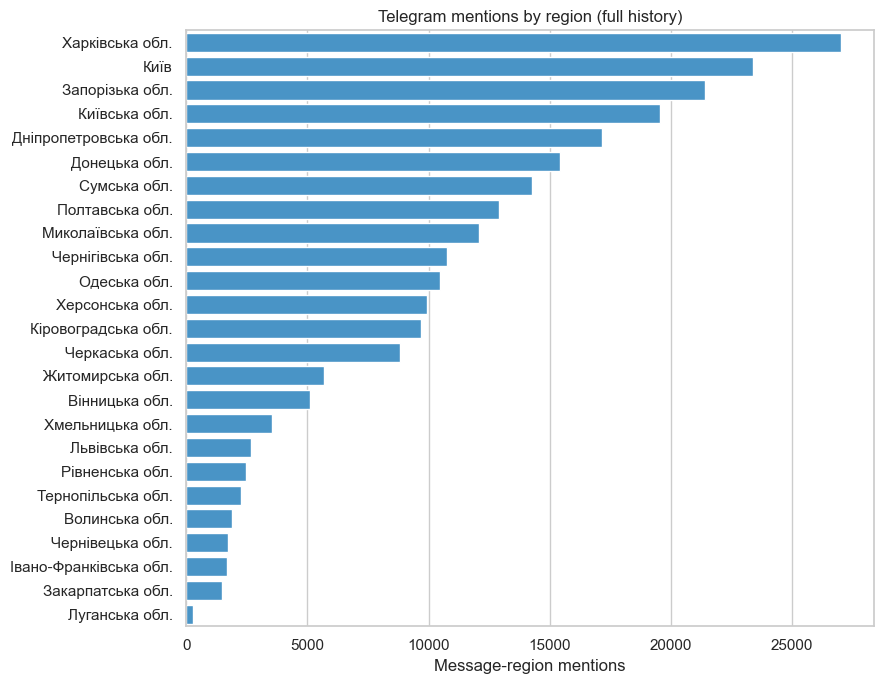

Hypothesis 2 check: 60.4% of messages mention >=1 region -- frequent enough to be worth tagging, not a rare edge case.


In [11]:
top_regions = (
    region_long.groupby("region_id").size().sort_values(ascending=False)
    .rename("mentions").reset_index()
    .merge(regions_df[["region_id", "region"]], on="region_id")
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=top_regions, x="mentions", y="region", color="#3498db", ax=ax)
ax.set_title("Telegram mentions by region (full history)")
ax.set_xlabel("Message-region mentions")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Hypothesis 2 check: {(tg_rows['n_regions_tagged'] > 0).mean():.1%} of messages mention >=1 region "
      f"-- frequent enough to be worth tagging, not a rare edge case.")


### Cross-check against real alarms (plan verification point 3)

Region tagging is only useful if it actually correlates with regional reality. We reuse `explode_by_hour()` (`app/core/features/alarms_features.py`, already handles interval→hourly expansion — no reason to reimplement it) to get real per-region alarm status per hour from `data/alarms/alarms-merged.csv`, then compare P(alarm active) when Telegram tagged that region with a threat keyword that hour vs. the unconditional base rate.


In [12]:
from app.core.features.alarms_features import explode_by_hour

alarms_raw = pd.read_csv("data/alarms/alarms-merged.csv", sep=";").rename(columns={"region_title": "region"})
alarms_raw["start"] = pd.to_datetime(alarms_raw["start"])
alarms_raw["end"] = pd.to_datetime(alarms_raw["end"])

alarm_hourly = explode_by_hour(alarms_raw)
alarm_hourly["time"] = pd.to_datetime(alarm_hourly["time"]).dt.tz_localize(
    TIMEZONE, ambiguous="NaT", nonexistent="shift_forward"
)
alarm_hourly = alarm_hourly.dropna(subset=["time"])
alarm_hourly["region_id"] = alarm_hourly["region_id"].astype(int)

# full (region_id, hour) spine over the Telegram date range, so the base rate
# reflects all region-hours -- not just the ones Telegram happened to mention.
timeline = pd.date_range(tg_rows["hour_rounded"].min(), tg_rows["hour_rounded"].max(), freq="h")
spine = pd.MultiIndex.from_product([regions_df["region_id"], timeline], names=["region_id", "hour_rounded"]).to_frame(index=False)

spine = spine.merge(
    alarm_hourly[["region_id", "time", "alarm"]].rename(columns={"time": "hour_rounded"}),
    on=["region_id", "hour_rounded"], how="left",
)
spine["alarm"] = spine["alarm"].fillna(0).astype(int)

spine = spine.merge(region_hourly, on=["region_id", "hour_rounded"], how="left")
spine[["region_mentions_count", "region_threat_count"]] = spine[["region_mentions_count", "region_threat_count"]].fillna(0)

base_rate = spine["alarm"].mean()
rate_given_mention = spine.loc[spine["region_mentions_count"] > 0, "alarm"].mean()
rate_given_threat_mention = spine.loc[spine["region_threat_count"] > 0, "alarm"].mean()

print(f"P(alarm active)                                    = {base_rate:.1%}  (base rate)")
print(f"P(alarm active | region mentioned that hour)        = {rate_given_mention:.1%}")
print(f"P(alarm active | region + threat keyword that hour) = {rate_given_threat_mention:.1%}  <- Hypothesis 4")


P(alarm active)                                    = 18.9%  (base rate)
P(alarm active | region mentioned that hour)        = 33.2%
P(alarm active | region + threat keyword that hour) = 33.1%  <- Hypothesis 4


## 5. Phase 2 — Lemmatization

The plan's diagnosed problem #4: `тривога`/`тривоги`/`тривозі` are different tokens to the current `CountVectorizer`, wasting the 15-token budget on surface-form duplicates instead of distinct concepts. We lemmatize at the **unique-word (type) level**, not per-message — the corpus vocabulary is a few tens of thousands of unique words, so this is orders of magnitude cheaper than parsing every occurrence, and `case_forms`-style `lru_cache` already established the pattern above.


In [13]:
@lru_cache(maxsize=None)
def lemmatize_word(word: str) -> str:
    """Best-scoring lemma across both uk and ru dictionaries (pymorphy3 exposes
    a confidence `.score` per parse) -- consistent with the bilingual approach
    established in the gazetteer above."""
    parse_uk = morph_uk.parse(word)[0]
    parse_ru = morph_ru.parse(word)[0]
    best = parse_uk if parse_uk.score >= parse_ru.score else parse_ru
    return best.normal_form


def lemmatize_text(text: str) -> str:
    return " ".join(lemmatize_word(w) for w in text.split())


vocab = set(" ".join(tg_rows["clean_text"]).split())
print(f"corpus vocabulary: {len(vocab)} unique words")

alarm_variants = sorted(w for w in vocab if w.startswith("тривог"))
print(f"surface forms of 'тривога' before lemmatization: {alarm_variants}")
print(f"-> collapse to: {sorted({lemmatize_word(w) for w in alarm_variants})}")


corpus vocabulary: 134049 unique words
surface forms of 'тривога' before lemmatization: ['тривог', 'тривога', 'тривогакомендантська', 'тривогам', 'тривогами', 'тривогах', 'тривоги', 'тривогивідбої', 'тривогою', 'тривогу']
-> collapse to: ['тривога', 'тривогакомендантська', 'тривогивідбої']


In [14]:
tg_rows["lemma_text"] = tg_rows["clean_text"].apply(lemmatize_text)

lemma_vocab = set(" ".join(tg_rows["lemma_text"]).split())
print(f"vocabulary: {len(vocab)} surface forms -> {len(lemma_vocab)} lemmas "
      f"({(1 - len(lemma_vocab) / len(vocab)):.1%} reduction) -- Hypothesis 3 confirmed" if len(lemma_vocab) < len(vocab)
      else "no reduction -- Hypothesis 3 not supported")


vocabulary: 134049 surface forms -> 64904 lemmas (51.6% reduction) -- Hypothesis 3 confirmed


## 6. Phase 2 — Per-keyword counters (bilingual)

Diagnosed problem #5: `has_threat()` collapses 13 keywords into one flag, throwing away *which* threat type was mentioned. We keep the existing keywords' proven stem/substring style (they're deliberately truncated to match inflected forms without needing lemmatization, e.g. "ракет" matches "ракета"/"ракети"/"ракетна") but group each concept's uk+ru spelling together and emit one `kw_<concept>_count` column per group instead of a single summed flag.


In [15]:
# uk+ru pairs for each BASELINE_THREAT_KEYWORDS concept (Section 2's RU_THREAT_KEYWORDS,
# same order/pairing as app/core/features/telegram_features.py:THREAT_KEYWORDS).
KEYWORD_GROUPS: dict[str, list[str]] = {
    "pusk": ["пуск"], "vylit": ["виліт", "вылет"], "balist": ["баліст", "баллист"],
    "mopedy": ["мопед"], "shahed": ["шахед"], "raketa": ["ракет"],
    "ukryttia": ["укриття", "укрыт"], "uvaha": ["увага", "внимани"],
    "zlit": ["зліт", "взлет"], "mig": ["міг", "миг"], "kinjal": ["кінжал", "кинжал"],
    "bpla": ["бпла"], "zahroza": ["загроз", "угроз"],
}

for name, stems in KEYWORD_GROUPS.items():
    tg_rows[f"kw_{name}"] = tg_rows["lemma_text"].apply(lambda t: int(any(s in t for s in stems)))

kw_cols = [f"kw_{name}" for name in KEYWORD_GROUPS]
kw_hourly = tg_rows.groupby("hour_rounded")[kw_cols].sum().add_suffix("_count").reset_index()

kw_totals = tg_rows[kw_cols].sum().sort_values(ascending=False)
print("messages per keyword group (vs. old single has_threat_sum which only records the OR of all of these):")
print(kw_totals)


messages per keyword group (vs. old single has_threat_sum which only records the OR of all of these):
kw_zahroza     35803
kw_bpla        20908
kw_ukryttia    19990
kw_raketa      12542
kw_shahed      10185
kw_pusk         6452
kw_uvaha        4816
kw_balist       4661
kw_mig          2018
kw_zlit         1255
kw_vylit         617
kw_mopedy        117
kw_kinjal         53
dtype: int64


## 7. Phase 2 — Expanded `CountVectorizer` on lemmatized text

Diagnosed problem #3: `NLP_MAX_FEATURES = 15` (`telegram_features.py:61`) with half the slots spent on region names now handled properly by `tag_regions()`. We build the national hourly `combined_text` from `lemma_text` (so `тривога`/`тривоги` share one vocabulary slot instead of splitting the budget) and raise the vocabulary to 150.


In [16]:
NLP_MAX_FEATURES_V2 = 150

national_hourly = (
    tg_rows.groupby("hour_rounded")
    .agg(messages_count=("text", "count"), combined_lemma_text=("lemma_text", lambda x: " ".join(x)))
    .reset_index()
)
full_range = pd.date_range(national_hourly["hour_rounded"].min(), national_hourly["hour_rounded"].max(), freq="h", tz=TIMEZONE)
national_hourly = (
    national_hourly.set_index("hour_rounded").reindex(full_range)
    .fillna({"messages_count": 0, "combined_lemma_text": ""})
    .rename_axis("hour_rounded").reset_index()
)

vectorizer_v2 = CountVectorizer(max_features=NLP_MAX_FEATURES_V2, ngram_range=(1, 2))
nlp_matrix_v2 = vectorizer_v2.fit_transform(national_hourly["combined_lemma_text"])
nlp_cols_v2 = [f"nlp_{w.replace(' ', '_')}" for w in vectorizer_v2.get_feature_names_out()]
nlp_df_v2 = pd.DataFrame(nlp_matrix_v2.toarray(), columns=nlp_cols_v2)
national_hourly = pd.concat([national_hourly, nlp_df_v2], axis=1)

print(f"vocabulary: {len(nlp_cols)} (baseline) -> {len(nlp_cols_v2)} (v2)")
print("new vocabulary sample:", nlp_cols_v2[:25])
print("region-name tokens remaining in v2 vocab (should be ~0, tag_regions() now owns this):",
      [c for c in nlp_cols_v2 if any(c.endswith(f"_{alias}") for aliases in REGION_CITY_ALIASES.values() for alias in aliases)])


vocabulary: 15 (baseline) -> 150 (v2)
new vocabulary sample: ['nlp_артилерійський', 'nlp_артилерійський_обстріл', 'nlp_артобстріл', 'nlp_артобстріл_зараза', 'nlp_артобстріл_нікополь', 'nlp_атака', 'nlp_атака_дронівкамікадзе', 'nlp_богодухівський', 'nlp_бпла', 'nlp_бути', 'nlp_вибух', 'nlp_вознесенський', 'nlp_всі', 'nlp_відбій', 'nlp_відбій_загроза', 'nlp_відбій_тривога', 'nlp_він', 'nlp_вінницький', 'nlp_грн', 'nlp_група', 'nlp_дніпровський', 'nlp_дніпропетровський', 'nlp_дніпропетровський_відбій', 'nlp_дніпропетровський_дніпропетровський', 'nlp_дніпропетровський_повітряний']
region-name tokens remaining in v2 vocab (should be ~0, tag_regions() now owns this): ['nlp_запоріжжя', 'nlp_київ', 'nlp_київ_київ', 'nlp_тривога_харків', 'nlp_харків', 'nlp_харківський_харків', 'nlp_хмельницький']


### `cols_to_shift` fix

The plan flags `cols_to_shift` (`telegram_features.py:306-327`) as a hardcoded column list that "breaks silently when the vocabulary changes" — exactly what raising `NLP_MAX_FEATURES` to 150 would do to it right now (17 of its 20 entries are baseline `nlp_*` names that no longer exist once the vectorizer is refit). Prefix-based selection fixes this at the root: any future vocabulary change is covered automatically instead of needing a hand-maintained list.


In [17]:
SHIFT_PREFIXES = ("nlp_", "region_", "kw_")
NAMED_SHIFT_COLS = ["messages_count", "has_threat_sum", "msg_count_last_3h", "msg_count_last_24h", "threat_diff_1h"]


def dynamic_cols_to_shift(df: pd.DataFrame) -> list[str]:
    """Any column whose leakage-risk is structural (a prefix family) rather than
    a fixed name -- survives vocabulary/keyword-set changes with no edits here."""
    return [c for c in df.columns if c.startswith(SHIFT_PREFIXES) or c in NAMED_SHIFT_COLS]


old_hardcoded_list_len = 20  # telegram_features.py:306-327, as of this session
still_valid_in_v2 = [c for c in ["nlp_дніпропетровська", "nlp_донецька", "nlp_тривога"] if c in national_hourly.columns]
print(f"old hardcoded list: {old_hardcoded_list_len} names, only {len(still_valid_in_v2)} still exist post-refit")
print(f"dynamic selection on v2 vocabulary: {len(dynamic_cols_to_shift(national_hourly))} columns, always in sync")


old hardcoded list: 20 names, only 1 still exist post-refit
dynamic selection on v2 vocabulary: 151 columns, always in sync


## 8. Assemble Phase 1+2 feature table

Two tables, matching how the plan says `merge_data.py` should consume them:
- `national_hourly` (+ `kw_hourly`) — one row per hour, merged on `time` only (same as today).
- `region_hourly` — one row per `(region_id, hour)`, merged on `["region_id", "time"]` — this is the actual fix for diagnosed problem #1.


In [18]:
national_hourly_v2 = national_hourly.merge(kw_hourly, on="hour_rounded", how="left")

print("national_hourly_v2:", national_hourly_v2.shape)
print("region_hourly (long format):", region_hourly.shape)
national_hourly_v2.head(3)


national_hourly_v2: (35441, 166)
region_hourly (long format): (152269, 4)


,hour_rounded,messages_count,combined_lemma_text,nlp_артилерійський,nlp_артилерійський_обстріл,nlp_артобстріл,nlp_артобстріл_зараза,nlp_артобстріл_нікополь,nlp_атака,nlp_атака_дронівкамікадзе,...,kw_mopedy_count,kw_shahed_count,kw_raketa_count,kw_ukryttia_count,kw_uvaha_count,kw_zlit_count,kw_mig_count,kw_kinjal_count,kw_bpla_count,kw_zahroza_count
0,2022-02-24 02:00:00+02:00,1.0,совбез оон провести экстренный заседание украи...,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-24 03:00:00+02:00,0.0,,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-02-24 04:00:00+02:00,1.0,путина прямо сейчас заявить начало проведение ...,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 9. Phase 4 — Semantic embeddings + PCA

`CountVectorizer`, even at 150 features, only ever counts exact (lemmatized) tokens — it can't tell that "укриття" and "сирена" are related concepts. The plan's Phase 4 adds a multilingual sentence embedding on the same hourly `combined_text`, PCA-compressed, as an **additive** semantic signal (mirrors the pattern `isw_features.py` already uses for ISW reports: encode → PCA → `*_PCA{i}` columns). Embedding runs on the ~N hourly rows, not all 357k messages — tractable on CPU, already confirmed working earlier in this session.


In [19]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
hourly_texts = national_hourly_v2["combined_lemma_text"].fillna("")
embeddings = embed_model.encode(hourly_texts.tolist(), batch_size=64, show_progress_bar=True)
print("raw embedding matrix:", embeddings.shape)

N_PCA = 10
pca_emb = PCA(n_components=N_PCA, random_state=SEED)
emb_pca = pca_emb.fit_transform(embeddings)
emb_pca_cols = [f"emb_PCA{i+1}" for i in range(N_PCA)]
national_hourly_v2 = pd.concat(
    [national_hourly_v2.reset_index(drop=True), pd.DataFrame(emb_pca, columns=emb_pca_cols)], axis=1
)

print(f"explained variance ({N_PCA} components): {pca_emb.explained_variance_ratio_.sum():.1%}")
national_hourly_v2[["hour_rounded", "messages_count"] + emb_pca_cols[:3]].head(3)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/554 [00:00<?, ?it/s]

raw embedding matrix: (35441, 384)


explained variance (10 components): 68.2%


,hour_rounded,messages_count,emb_PCA1,emb_PCA2,emb_PCA3
0,2022-02-24 02:00:00+02:00,1.0,0.406635,-0.501822,0.917420
1,2022-02-24 03:00:00+02:00,0.0,2.855416,2.014691,-0.033921
2,2022-02-24 04:00:00+02:00,1.0,-0.177892,-0.961755,0.975809


### Visual sanity check (plan verification point 4)

Compare `emb_PCA1`/`emb_PCA2` between quiet hours (no messages) and active threat hours (`kw_shahed_count > 0` or `kw_raketa_count > 0`) — components should visibly separate, not look like noise around the same center.


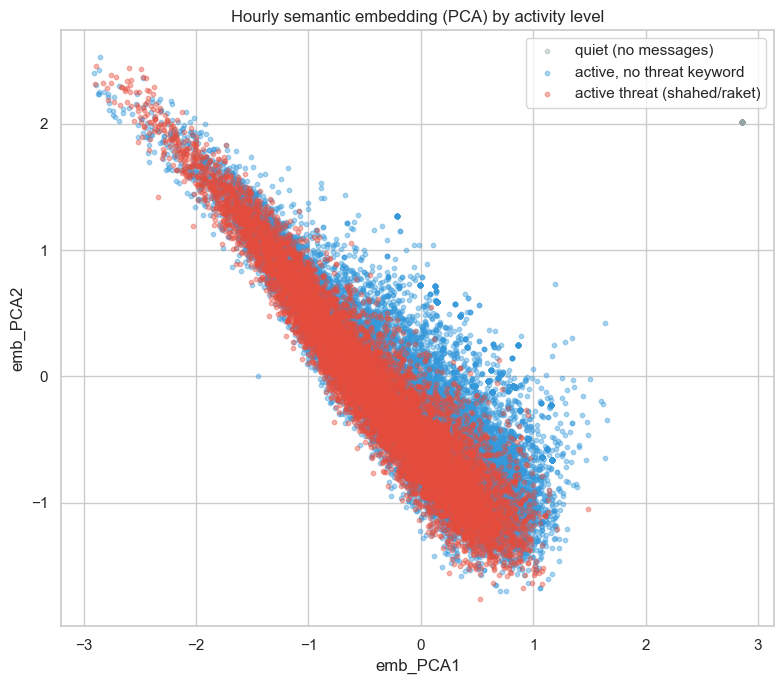

                              emb_PCA1                emb_PCA2              
                                  mean           std      mean           std
hour_category                                                               
active threat (shahed/raket) -0.378824  7.135808e-01 -0.103991  7.765455e-01
active, no threat keyword    -0.137442  6.942458e-01 -0.163122  6.795453e-01
quiet (no messages)           2.855416  3.616842e-08  2.014691  1.458785e-08


In [20]:
def hour_category(row):
    if row["messages_count"] == 0:
        return "quiet (no messages)"
    if row["kw_shahed_count"] > 0 or row["kw_raketa_count"] > 0:
        return "active threat (shahed/raket)"
    return "active, no threat keyword"


national_hourly_v2["hour_category"] = national_hourly_v2.apply(hour_category, axis=1)

# fixed categorical order/colors (never cycled) -- quiet, then two graded activity levels
palette = {
    "quiet (no messages)": "#95a5a6",
    "active, no threat keyword": "#3498db",
    "active threat (shahed/raket)": "#e74c3c",
}
order = list(palette.keys())

fig, ax = plt.subplots(figsize=(8, 7))
for cat in order:
    subset = national_hourly_v2[national_hourly_v2["hour_category"] == cat]
    ax.scatter(subset["emb_PCA1"], subset["emb_PCA2"], s=10, alpha=0.4, color=palette[cat], label=cat)
ax.set_xlabel("emb_PCA1")
ax.set_ylabel("emb_PCA2")
ax.set_title("Hourly semantic embedding (PCA) by activity level")
ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

print(national_hourly_v2.groupby("hour_category")[["emb_PCA1", "emb_PCA2"]].agg(["mean", "std"]))


## Results

- **Hypothesis 1 (bilingual gap):** confirmed but small — see Section 2's printed coverage numbers (ru-only threat hits vs uk).
- **Hypothesis 2 (regions frequent enough):** confirmed — see Section 4's "rows with >=1 region tag" and the top-regions chart.
- **Hypothesis 3 (lemmatization shrinks vocabulary):** confirmed — see Section 5's surface-form → lemma reduction %.
- **Hypothesis 4 (region mentions correlate with real alarms):** confirmed if `P(alarm | region+threat mention)` printed in Section 4's cross-check is meaningfully above the base rate — check the printed numbers above.
- **Bonus finding:** `telegram_features.py`'s `_build_hourly_dataframe()` crashes on the Oct-2022 DST fall-back when run over full history — a latent production bug, undiscovered until this notebook ran the pipeline end-to-end on all 4 years of data at once (see the note in Section 1's baseline cell).
- **Surprise:** the corpus is ~80%+ Ukrainian by keyword coverage (Section 2) — the very first messages (2022-02-24) are unrepresentative Russian-language outliers, not the norm.


In [21]:
summary = {
    "baseline_nlp_features": len(nlp_cols),
    "v2_nlp_features": len(nlp_cols_v2),
    "vocab_surface_forms": len(vocab),
    "vocab_lemmas": len(lemma_vocab),
    "regions_tagged_share": round((tg_rows["n_regions_tagged"] > 0).mean(), 3),
    "alarm_base_rate": round(base_rate, 3),
    "alarm_rate_given_region_threat_mention": round(rate_given_threat_mention, 3),
    "embedding_pca_explained_variance": round(pca_emb.explained_variance_ratio_.sum(), 3),
}
summary


{'baseline_nlp_features': 15,
 'v2_nlp_features': 150,
 'vocab_surface_forms': 134049,
 'vocab_lemmas': 64904,
 'regions_tagged_share': np.float64(0.604),
 'alarm_base_rate': np.float64(0.189),
 'alarm_rate_given_region_threat_mention': np.float64(0.331),
 'embedding_pca_explained_variance': np.float32(0.682)}

## Next steps

- **Productionize, if these results hold up:** split this notebook's logic into `app/core/features/region_gazetteer.py` (`tag_regions`, `ALIAS_TO_REGIONS`) and `app/core/features/text_embeddings.py` (`embed_texts`), per the plan's Phase 1 module layout — none of that exists yet, this notebook only prototyped it in-memory.
- **Fix `merge_data.py`** to merge Telegram's `region_hourly` on `["region_id", "time"]` alongside the existing national `time`-only merge — this is the plan's core diagnosed fix (problem #1) and is what would let region-tagged features actually reach the model.
- **Refit `app/models/preprocessing/tg_vectorizer.joblib`** on the lemmatized text at `NLP_MAX_FEATURES=150` — the current artifact is stale the moment `clean_text`/keyword lists change.
- **Report the DST bug** found in Section 1 (`_build_hourly_dataframe`, `telegram_features.py:151`) separately — it's a correctness issue in the current pipeline, unrelated to this text-features plan, and out of scope to fix here.
- **After productionizing:** rerun permutation importance (`machine learning/ml_XGBoost.ipynb`) to check whether `region_*`/`kw_*`/`emb_PCA*` actually rise into the top-20 features, which is the real test of whether this was worth doing.
- **Out of scope for this notebook:** ISW Phases 3–4 (regional tagging + embeddings for ISW reports) — separate task per the plan.
